## Phase 3 : Exploratory Data Analysis

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
#Load cleaned dataset
df = pd.read_csv("../data/processed/Superstore_Cleaned.csv")

In [15]:
#Convert date columns
df['Ship Date']=pd.to_datetime(df['Ship Date'])
df['Order Date']=pd.to_datetime(df['Order Date'])

In [16]:
#Total revenue
total_revenue=df['Sales'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $2,297,200.86


In [17]:
#Total profit
total_profit=df['Profit'].sum()
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [18]:
#Total customer
total_customer = df['Customer ID'].nunique()
print(f"Total Customers: {total_customer}")

Total Customers: 793


In [19]:
## Question 1
## How has revenue changed over time

monthly_revenue = (
    df.groupby("Order Month Name")["Sales"]
      .sum()
      .reindex([
          "January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"
      ])
)

monthly_revenue

Order Month Name
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64

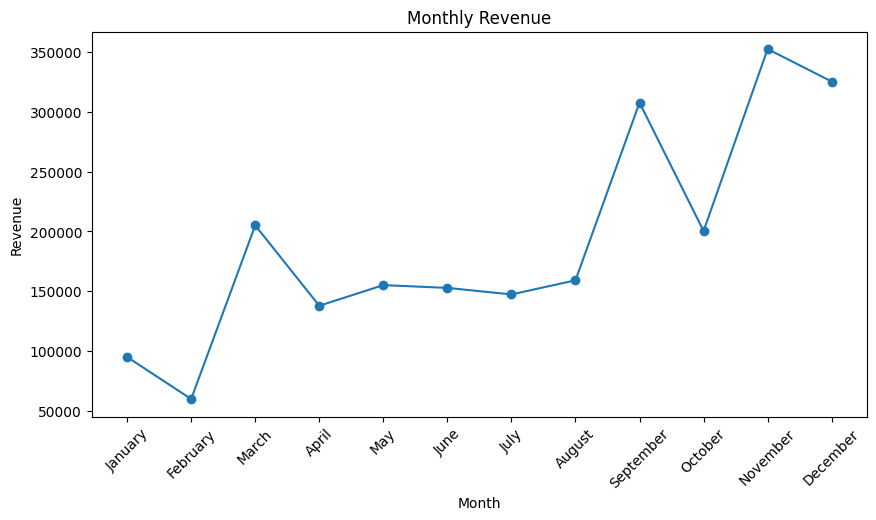

In [20]:
plt.figure(figsize=(10,5))

plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

In [21]:
## Question 2
## Which product category generate the most revenue

category_revenue = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

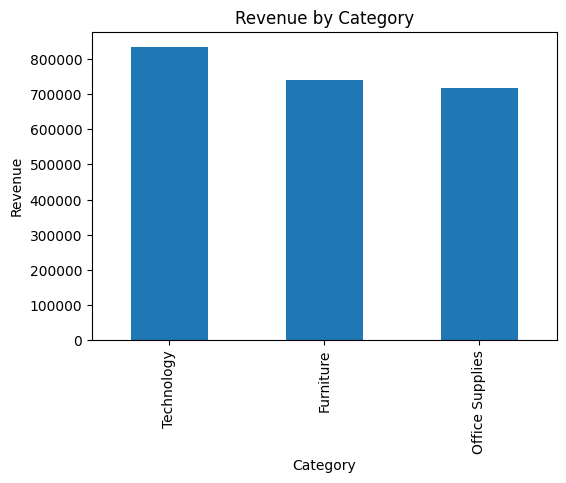

In [22]:
plt.figure(figsize=(6,4))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [23]:
## Question 3
## Which regions generate the highest revenue and profit

region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Sales", ascending=False)
)

region_summary

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


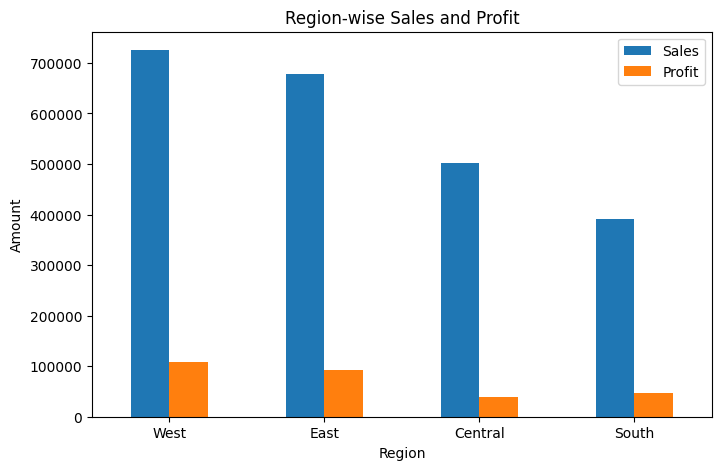

In [24]:
region_summary.plot(kind="bar", figsize=(8,5))

plt.title("Region-wise Sales and Profit")
plt.xlabel("Region")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.show()

### Insight
- Highest Revenue Region: Technology
- Lowest Revenue Region: Office Supplies
- Highest Profit Region: West
- Lowest Profit Region: South

### Business Recommendation